# EDA da Estação Iraja

Este notebook será usado para a análise exploratória individual da **Estação Iraja**. Nesta primeira etapa, vamos montar a **auditoria da base**, que serve para verificar se a série da estação é confiável e em quais períodos ela apresenta melhor ou pior qualidade.


## Carregamento da base

Primeiro, carregamos a base consolidada de qualidade do ar e isolamos apenas os registros da estação de Iraja. Como o nome da estação pode vir com problema de codificação, fazemos uma normalização simples para garantir um filtro robusto.


In [1]:
import pandas as pd
import unicodedata
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url_air_quality_data = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/InitialMergedData/merged_air_quality_data.csv"

df_air_quality = pd.read_csv(url_air_quality_data)
df_iraja = df_air_quality[df_air_quality["Nome"] == "ESTAÇÃO IRAJÁ"].copy()

print("Dimensoes da base da Estacao Iraja:", df_iraja.shape)
display(df_iraja.head())

Dimensoes da base da Estacao Iraja: (61368, 15)


,data,Nome,chuva,temp,ur,so2,no2,co,no,nox,o3,pm10,pm2_5,lat,lon
8,2012-01-01 00:30:00,ESTAÇÃO IRAJÁ,0.8,24.84,97.12,2.55,20.09,0.40,0.23,20.20,25.03,89.0,85.0,-22.831621,-43.326845
9,2012-01-01 01:30:00,ESTAÇÃO IRAJÁ,0.0,24.68,96.00,0.45,18.91,0.35,0.68,19.60,22.95,33.0,32.0,-22.831621,-43.326845
18,2012-01-01 02:30:00,ESTAÇÃO IRAJÁ,0.0,24.56,96.39,0.11,17.99,0.34,0.39,18.33,22.31,19.0,14.0,-22.831621,-43.326845
30,2012-01-01 03:30:00,ESTAÇÃO IRAJÁ,0.0,24.65,96.87,0.70,22.49,0.37,0.44,22.93,17.98,12.0,12.0,-22.831621,-43.326845
37,2012-01-01 04:30:00,ESTAÇÃO IRAJÁ,0.0,24.66,96.32,0.79,21.28,0.32,0.24,21.52,18.88,10.0,10.0,-22.831621,-43.326845


## Auditoria da base


### 1. Período coberto e frequência observada

Nesta célula verificamos o intervalo temporal da base, o número de timestamps únicos, o intervalo mais frequente entre observações e a distribuição do minuto da medição. Isso ajuda a confirmar se a série realmente se comporta como uma série **horária**.


In [3]:
df_iraja["data"] = pd.to_datetime(df_iraja["data"], errors="coerce")

timestamps_unicos = df_iraja["data"].drop_duplicates().sort_values()
intervalos = timestamps_unicos.diff().dropna()

intervalo_modal = intervalos.mode().iloc[0] if not intervalos.empty else pd.Timedelta(hours=1)

resumo_periodo = pd.DataFrame(
    {
        "metrica": [
            "primeira_medicao",
            "ultima_medicao",
            "n_linhas",
            "anos_cobertos",
        ],
        "valor": [
            timestamps_unicos.min(),
            timestamps_unicos.max(),
            len(df_iraja),
            df_iraja["data"].dt.year.nunique(),
        ],
    }
)

display(resumo_periodo)

,metrica,valor
0,primeira_medicao,2012-01-01 00:30:00
1,ultima_medicao,2018-12-31 23:30:00
2,n_linhas,61368
3,anos_cobertos,7


### 2. Datas faltantes e cobertura temporal

Agora montamos um calendário esperado usando o intervalo modal da série e verificamos:

- quantos timestamps estão faltando no período total;
- quais são alguns exemplos de lacunas;
- como a **completude** se comporta por ano e por mês.

Esse bloco é importante porque, mesmo que a estação tenha um período longo, ela pode ter meses com baixa confiabilidade.


In [4]:
indice_esperado = pd.date_range(timestamps_unicos.min(), timestamps_unicos.max(), freq=intervalo_modal)
timestamps_faltantes = indice_esperado.difference(timestamps_unicos)

print("Quantidade de timestamps esperados:", len(indice_esperado))
print("Quantidade de timestamps observados:", len(timestamps_unicos))
print("Quantidade de timestamps faltantes:", len(timestamps_faltantes))

if len(timestamps_faltantes) > 0:
    display(pd.DataFrame({"data_faltante": timestamps_faltantes[:20]}))
else:
    print("Nao foram encontrados timestamps faltantes na serie.")

df_cobertura = pd.DataFrame({"data": indice_esperado})
df_cobertura["observada"] = df_cobertura["data"].isin(timestamps_unicos).astype(int)
df_cobertura["ano"] = df_cobertura["data"].dt.year
df_cobertura["mes"] = df_cobertura["data"].dt.month
df_cobertura["ano_mes"] = df_cobertura["data"].dt.to_period("M").astype(str)

cobertura_anual = (
    df_cobertura.groupby("ano", as_index=False)
    .agg(
        medicoes_esperadas=("observada", "size"),
        medicoes_observadas=("observada", "sum"),
    )
)
cobertura_anual["faltantes"] = cobertura_anual["medicoes_esperadas"] - cobertura_anual["medicoes_observadas"]
cobertura_anual["completude_pct"] = (100 * cobertura_anual["medicoes_observadas"] / cobertura_anual["medicoes_esperadas"]).round(2)

cobertura_mensal = (
    df_cobertura.groupby(["ano_mes", "ano", "mes"], as_index=False)
    .agg(
        medicoes_esperadas=("observada", "size"),
        medicoes_observadas=("observada", "sum"),
    )
)
cobertura_mensal["faltantes"] = cobertura_mensal["medicoes_esperadas"] - cobertura_mensal["medicoes_observadas"]
cobertura_mensal["completude_pct"] = (100 * cobertura_mensal["medicoes_observadas"] / cobertura_mensal["medicoes_esperadas"]).round(2)

display(cobertura_anual)
display(cobertura_mensal.sort_values(["completude_pct", "ano_mes"]).head(15))

Quantidade de timestamps esperados: 61368
Quantidade de timestamps observados: 61368
Quantidade de timestamps faltantes: 0
Nao foram encontrados timestamps faltantes na serie.


,ano,medicoes_esperadas,medicoes_observadas,faltantes,completude_pct
0,2012,8784,8784,0,100.0
1,2013,8760,8760,0,100.0
2,2014,8760,8760,0,100.0
3,2015,8760,8760,0,100.0
4,2016,8784,8784,0,100.0
5,2017,8760,8760,0,100.0
6,2018,8760,8760,0,100.0


,ano_mes,ano,mes,medicoes_esperadas,medicoes_observadas,faltantes,completude_pct
0,2012-01,2012,1,744,744,0,100.0
1,2012-02,2012,2,696,696,0,100.0
2,2012-03,2012,3,744,744,0,100.0
3,2012-04,2012,4,720,720,0,100.0
4,2012-05,2012,5,744,744,0,100.0
5,2012-06,2012,6,720,720,0,100.0
6,2012-07,2012,7,744,744,0,100.0
7,2012-08,2012,8,744,744,0,100.0
8,2012-09,2012,9,720,720,0,100.0
9,2012-10,2012,10,744,744,0,100.0


### 3. Colunas totalmente vazias e percentual de missing por variável

Nesta etapa medimos a completude de cada coluna. Isso ajuda a responder, por exemplo, se algum poluente praticamente não existe na série, se uma variável tem muitos vazios em certos períodos ou se alguma coluna está completamente inútil para análise.


In [5]:
missing_por_variavel = pd.DataFrame(
    {
        "coluna": df_iraja.columns,
        "n_missing": df_iraja.isna().sum().values,
        "missing_pct": (100 * df_iraja.isna().mean()).round(2).values,
    }
)

missing_por_variavel = missing_por_variavel.sort_values(["missing_pct", "coluna"], ascending=[False, True]).reset_index(drop=True)
colunas_totalmente_vazias = missing_por_variavel[missing_por_variavel["missing_pct"] == 100].copy()

print("Quantidade de colunas totalmente vazias:", len(colunas_totalmente_vazias))

if len(colunas_totalmente_vazias) > 0:
    display(colunas_totalmente_vazias)
else:
    print("Nenhuma coluna esta completamente vazia.")

display(missing_por_variavel)

Quantidade de colunas totalmente vazias: 0
Nenhuma coluna esta completamente vazia.


,coluna,n_missing,missing_pct
0,so2,16327,26.61
1,ur,10907,17.77
2,pm2_5,5968,9.72
3,o3,5103,8.32
4,nox,5048,8.23
5,no,5043,8.22
6,no2,5041,8.21
7,temp,4190,6.83
8,pm10,4049,6.60
9,co,3653,5.95


## Caracterização inicial das variáveis

Nesta etapa, o objetivo é entender o **nível típico**, a **dispersão** e o **formato da distribuição** de cada poluente e variável meteorológica da estação.

Para isso, vamos olhar:

- média, mediana, desvio padrão, quartis, mínimo, máximo e assimetria;
- histogramas das distribuições;
- distribuição de **nulos por dia** para cada variável.

Esse último ponto é especialmente importante porque ele ajuda a identificar quais variáveis têm dias com poucas horas faltantes, o que pode apoiar um tratamento futuro de imputação em dias com, por exemplo, menos de 4 horas ausentes.


### Preparando as variáveis da seção

Primeiro, separamos explicitamente as variáveis meteorológicas e os poluentes, padronizamos os tipos numéricos e criamos uma coluna de `data_dia` para apoiar a análise de nulos diários.


In [6]:
variaveis_meteorologicas = ["chuva", "temp", "ur"]
poluentes = ["so2", "no2", "co", "no", "nox", "o3", "pm10", "pm2_5"]
variaveis_analise = [coluna for coluna in variaveis_meteorologicas + poluentes if coluna in df_iraja.columns]

df_iraja_carac = df_iraja.copy()
df_iraja_carac["data"] = pd.to_datetime(df_iraja_carac["data"], errors="coerce")
df_iraja_carac["data_dia"] = df_iraja_carac["data"].dt.normalize()

for coluna in variaveis_analise:
    df_iraja_carac[coluna] = pd.to_numeric(df_iraja_carac[coluna], errors="coerce")

display(pd.DataFrame({
    "variavel": variaveis_analise,
    "tipo": ["meteorologica" if v in variaveis_meteorologicas else "poluente" for v in variaveis_analise],
}))

,variavel,tipo
0,chuva,meteorologica
1,temp,meteorologica
2,ur,meteorologica
3,so2,poluente
4,no2,poluente
5,co,poluente
6,no,poluente
7,nox,poluente
8,o3,poluente
9,pm10,poluente


### Estatísticas descritivas por variável

Aqui resumimos cada variável com medidas de posição, dispersão e forma. A comparação entre **média** e **mediana** ajuda a perceber assimetria; o **desvio padrão** e os **quartis** mostram a variabilidade; e a **assimetria** ajuda a identificar concentração de valores baixos com picos mais raros para cima.


In [7]:
estatisticas_variaveis = []

for variavel in variaveis_analise:
    serie = df_iraja_carac[variavel]
    estatisticas_variaveis.append(
        {
            "variavel": variavel,
            "tipo": "meteorologica" if variavel in variaveis_meteorologicas else "poluente",
            "n_validos": int(serie.notna().sum()),
            "n_missing": int(serie.isna().sum()),
            "missing_pct": round(100 * serie.isna().mean(), 2),
            "media": round(serie.mean(), 2),
            "mediana": round(serie.median(), 2),
            "desvio_padrao": round(serie.std(), 2),
            "q1": round(serie.quantile(0.25), 2),
            "q3": round(serie.quantile(0.75), 2),
            "min": round(serie.min(), 2),
            "max": round(serie.max(), 2),
            "assimetria": round(serie.skew(), 2),
        }
    )

estatisticas_variaveis = pd.DataFrame(estatisticas_variaveis)
estatisticas_variaveis = estatisticas_variaveis.sort_values(["tipo", "variavel"]).reset_index(drop=True)

display(estatisticas_variaveis)

,variavel,tipo,n_validos,n_missing,missing_pct,media,mediana,desvio_padrao,q1,q3,min,max,assimetria
0,chuva,meteorologica,59841,1527,2.49,0.13,0.00,1.26,0.00,0.00,0.0,88.00,24.99
1,temp,meteorologica,57178,4190,6.83,27.42,26.72,4.91,23.80,30.37,14.6,45.65,0.61
2,ur,meteorologica,50461,10907,17.77,66.32,68.50,17.94,53.48,80.03,0.0,100.00,-0.36
3,co,poluente,57715,3653,5.95,0.45,0.39,0.30,0.27,0.54,0.0,4.62,3.28
4,no,poluente,56325,5043,8.22,19.23,7.20,35.77,2.98,19.02,0.0,640.38,4.76
5,no2,poluente,56327,5041,8.21,41.96,38.63,20.51,27.22,52.30,0.0,197.76,1.35
6,nox,poluente,56320,5048,8.23,61.17,47.54,48.74,31.77,73.60,0.0,702.67,3.15
7,o3,poluente,56265,5103,8.32,33.36,24.43,33.40,7.50,48.32,0.0,355.45,1.67
8,pm10,poluente,57319,4049,6.60,38.02,32.00,24.58,22.00,48.00,0.0,409.00,2.18
9,pm2_5,poluente,55400,5968,9.72,17.53,14.00,14.81,8.00,23.00,0.0,370.00,2.91


### Nulos por dia por variável

Agora traduzimos os missings para uma lógica diária. Em vez de olhar apenas o percentual total de nulos, calculamos quantas **horas faltaram em cada dia** para cada variável.

Isso permite responder perguntas como:

- quantos dias estão completos;
- quantos dias têm apenas `1`, `2` ou `3` horários faltantes;
- quantos dias já estão em um nível de incompletude mais severo.

Essa leitura é muito útil para decidir, no futuro, se vale imputar dias com menos de 4 horas ausentes.


In [8]:
timestamps_carac = df_iraja_carac["data"].dropna().drop_duplicates().sort_values()
intervalos_carac = timestamps_carac.diff().dropna()
intervalo_modal_carac = intervalos_carac.mode().iloc[0] if not intervalos_carac.empty else pd.Timedelta(hours=1)

# Convertendo o intervalo modal para quantidade esperada de medicoes por dia.
medicoes_esperadas_por_dia = int(pd.Timedelta(days=1) / intervalo_modal_carac)
indice_dias = pd.date_range(df_iraja_carac["data_dia"].min(), df_iraja_carac["data_dia"].max(), freq="D")

distribuicoes_missing_diario = {}
resumo_missing_diario = []

for variavel in variaveis_analise:
    validas_por_dia = df_iraja_carac.groupby("data_dia")[variavel].apply(lambda s: s.notna().sum())
    validas_por_dia = validas_por_dia.reindex(indice_dias, fill_value=0)

    faltantes_por_dia = medicoes_esperadas_por_dia - validas_por_dia
    faltantes_por_dia = faltantes_por_dia.clip(lower=0)

    distribuicoes_missing_diario[variavel] = faltantes_por_dia

    resumo_missing_diario.append(
        {
            "variavel": variavel,
            "tipo": "meteorologica" if variavel in variaveis_meteorologicas else "poluente",
            "medicoes_esperadas_por_dia": medicoes_esperadas_por_dia,
            "dias_no_periodo": len(indice_dias),
            "dias_sem_falta": int((faltantes_por_dia == 0).sum()),
            "dias_com_1_a_4_faltantes": int(((faltantes_por_dia >= 1) & (faltantes_por_dia <= 4)).sum()),
            "pct_dias_com_ate_4_faltantes": round(100 * ((faltantes_por_dia >= 1) & (faltantes_por_dia <= 4)).mean(), 2),
            "dias_com_5_ou_mais_faltantes": int((faltantes_por_dia >= 5).sum()),
        }
    )

resumo_missing_diario = pd.DataFrame(resumo_missing_diario)
resumo_missing_diario = resumo_missing_diario.sort_values(["tipo", "variavel"]).reset_index(drop=True)

print("Intervalo modal considerado:", intervalo_modal_carac)
print("Medicoes esperadas por dia:", medicoes_esperadas_por_dia)
display(resumo_missing_diario)

Intervalo modal considerado: 0 days 01:00:00
Medicoes esperadas por dia: 24


,variavel,tipo,medicoes_esperadas_por_dia,dias_no_periodo,dias_sem_falta,dias_com_1_a_4_faltantes,pct_dias_com_ate_4_faltantes,dias_com_5_ou_mais_faltantes
0,chuva,meteorologica,24,2557,2364,99,3.87,94
1,temp,meteorologica,24,2557,2158,181,7.08,218
2,ur,meteorologica,24,2557,1883,171,6.69,503
3,co,poluente,24,2557,2054,307,12.01,196
4,no,poluente,24,2557,1785,512,20.02,260
5,no2,poluente,24,2557,1785,511,19.98,261
6,nox,poluente,24,2557,1784,512,20.02,261
7,o3,poluente,24,2557,2008,278,10.87,271
8,pm10,poluente,24,2557,1578,755,29.53,224
9,pm2_5,poluente,24,2557,1317,932,36.45,308


### Histogramas e distribuição de nulos por dia

Para cada variável, vamos visualizar dois aspectos ao mesmo tempo:

- `esquerda`: histograma da distribuição dos valores observados;
- `direita`: distribuição da quantidade de horas faltantes por dia.

No gráfico de nulos diários, a linha vermelha marca o limite de **4 horas faltantes**, que pode ser usado depois como critério de imputação.


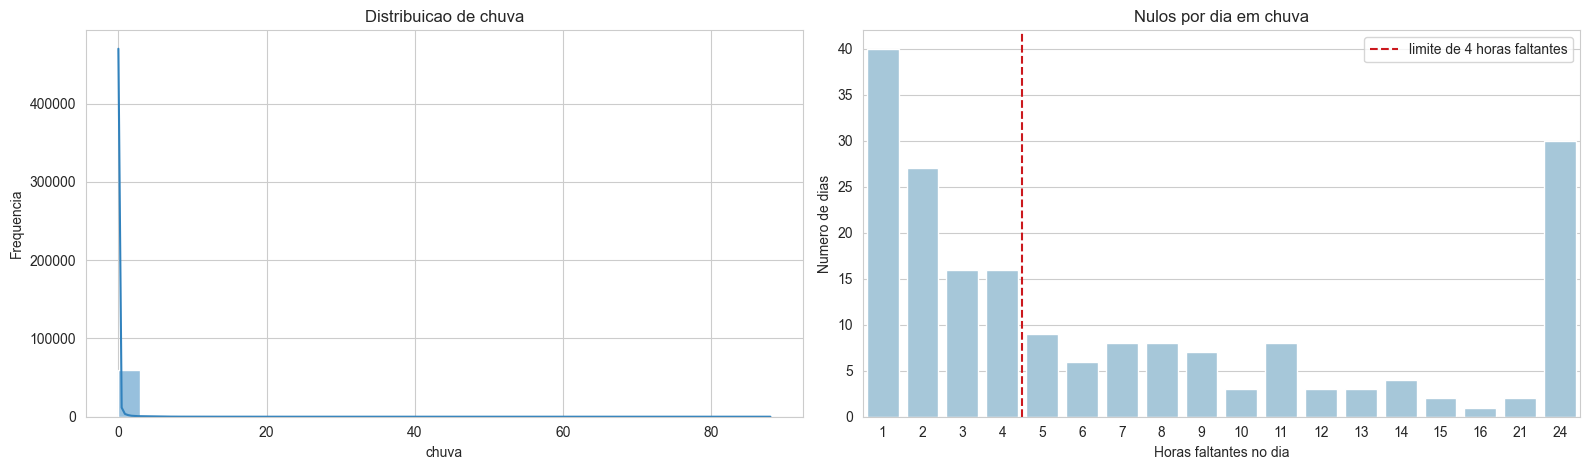

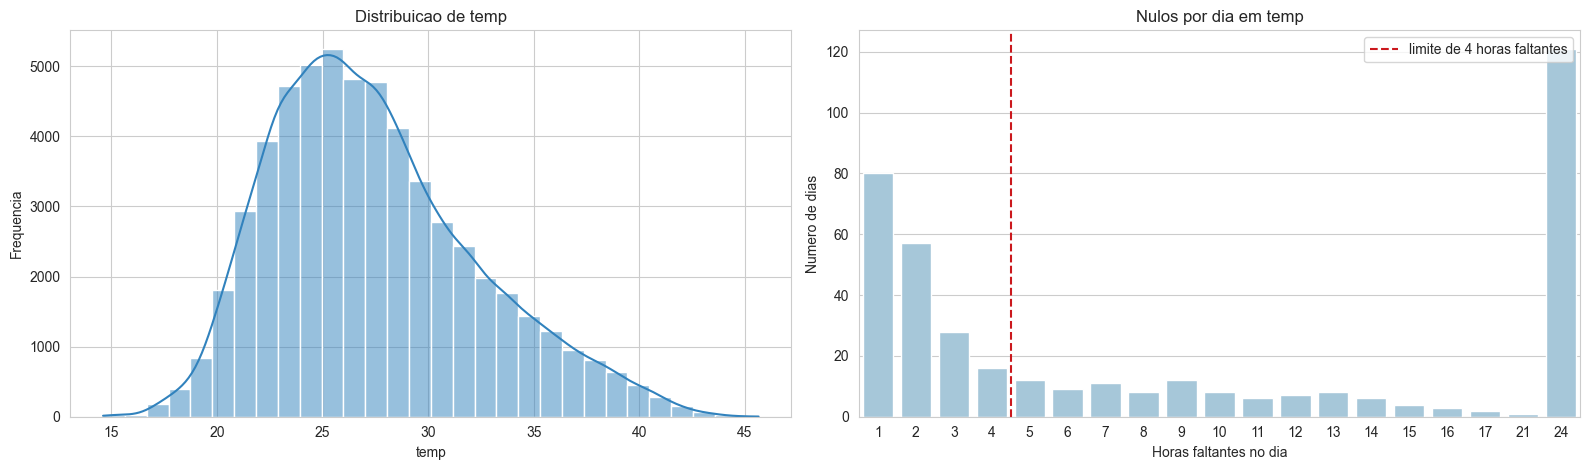

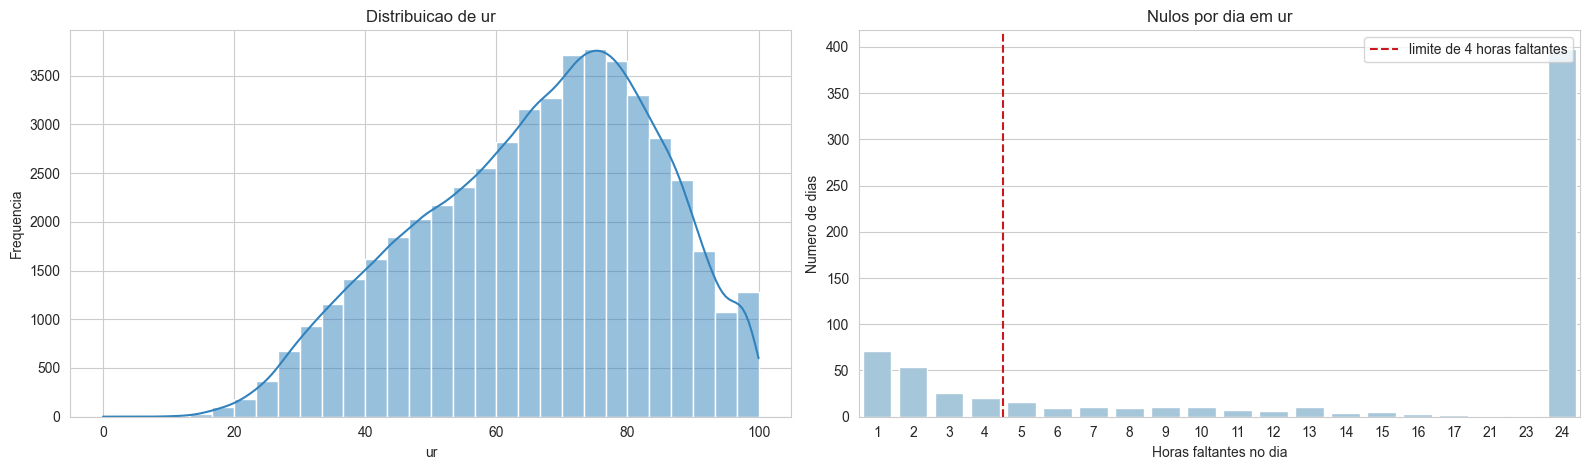

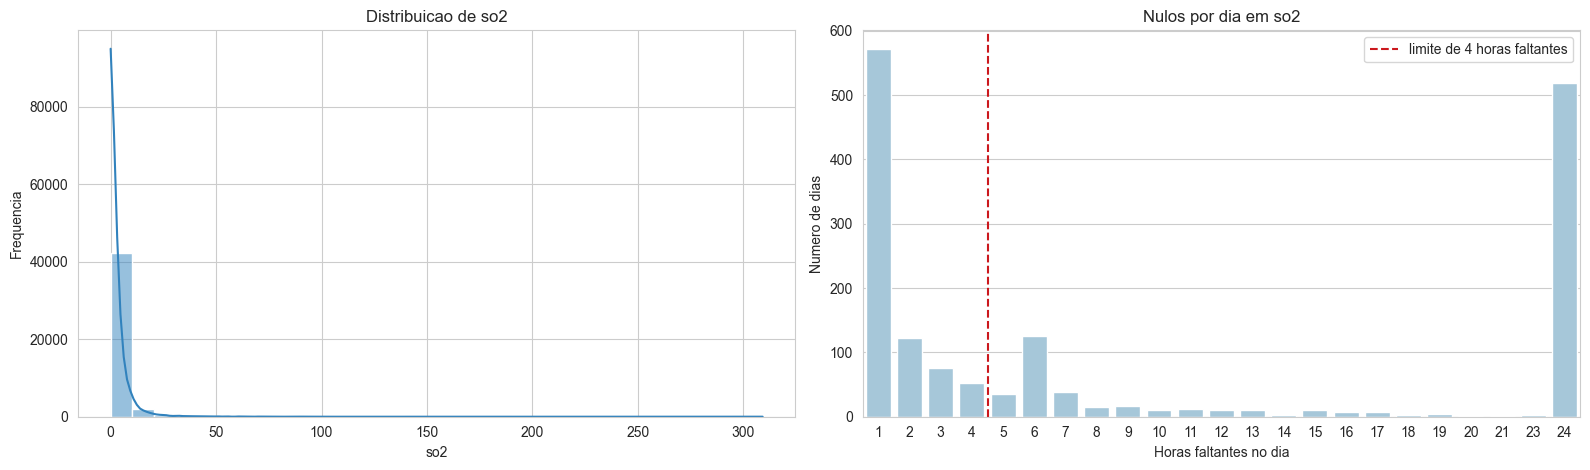

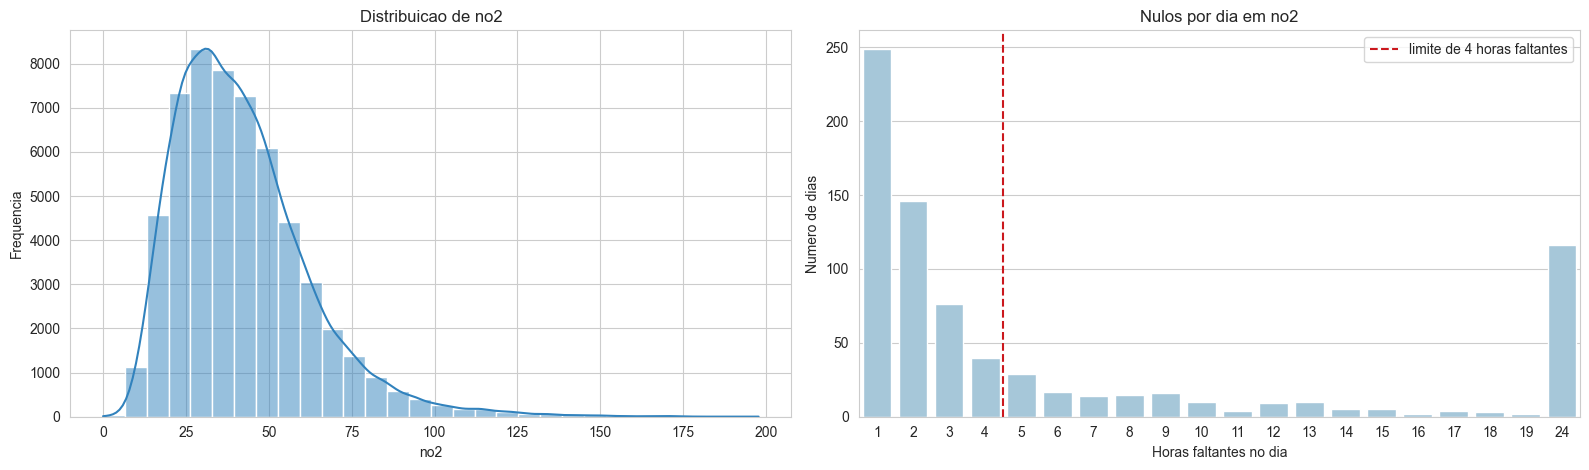

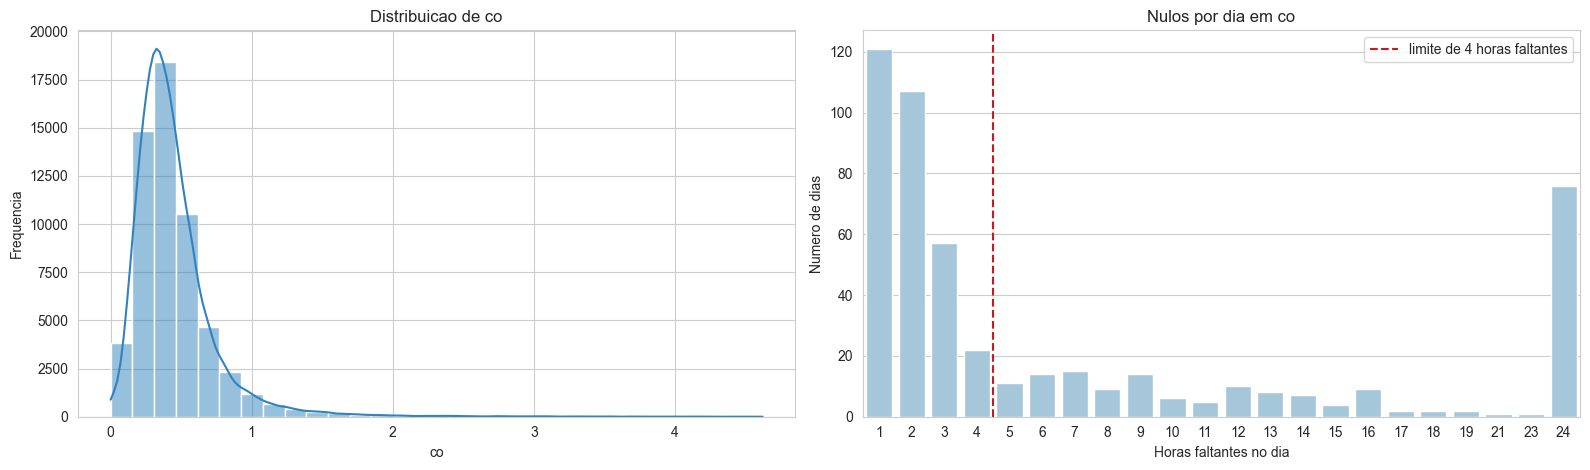

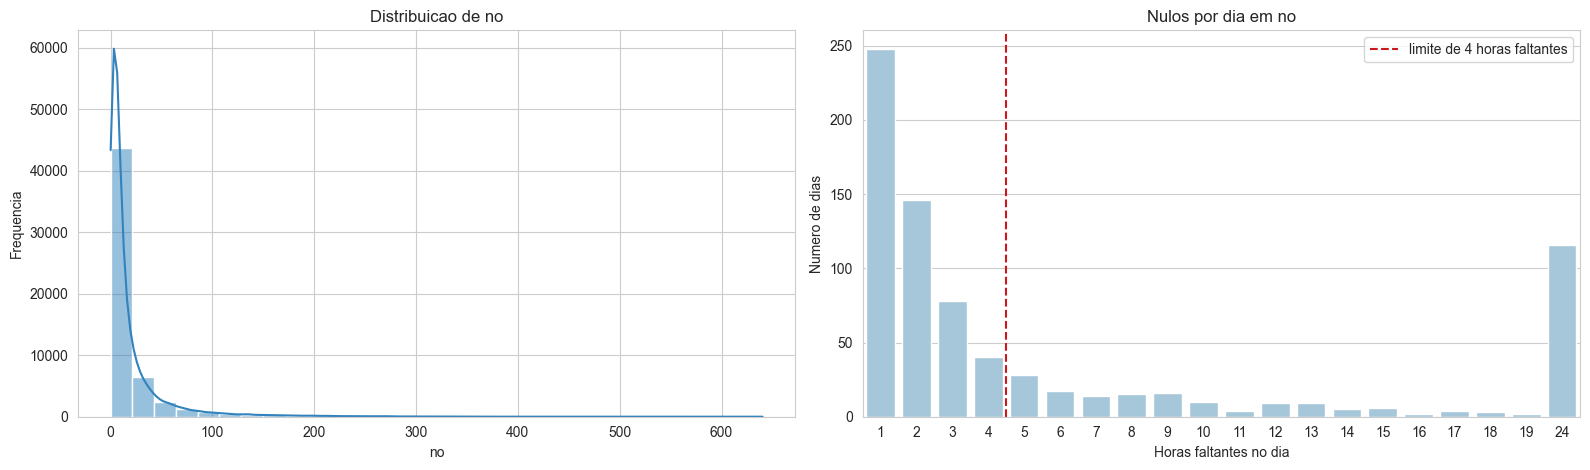

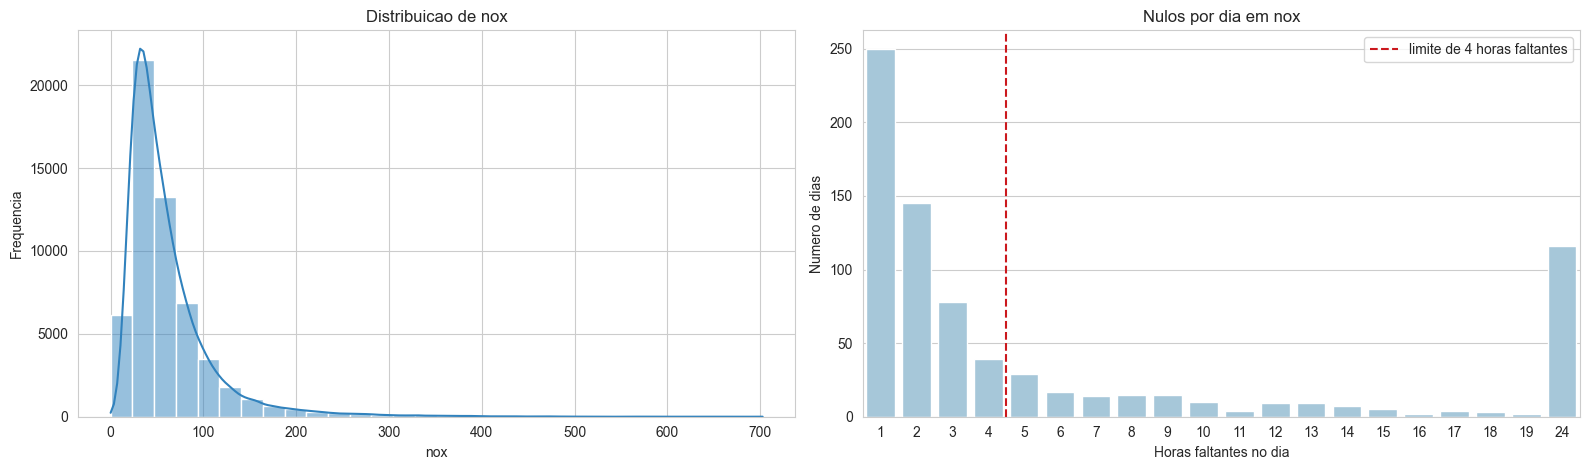

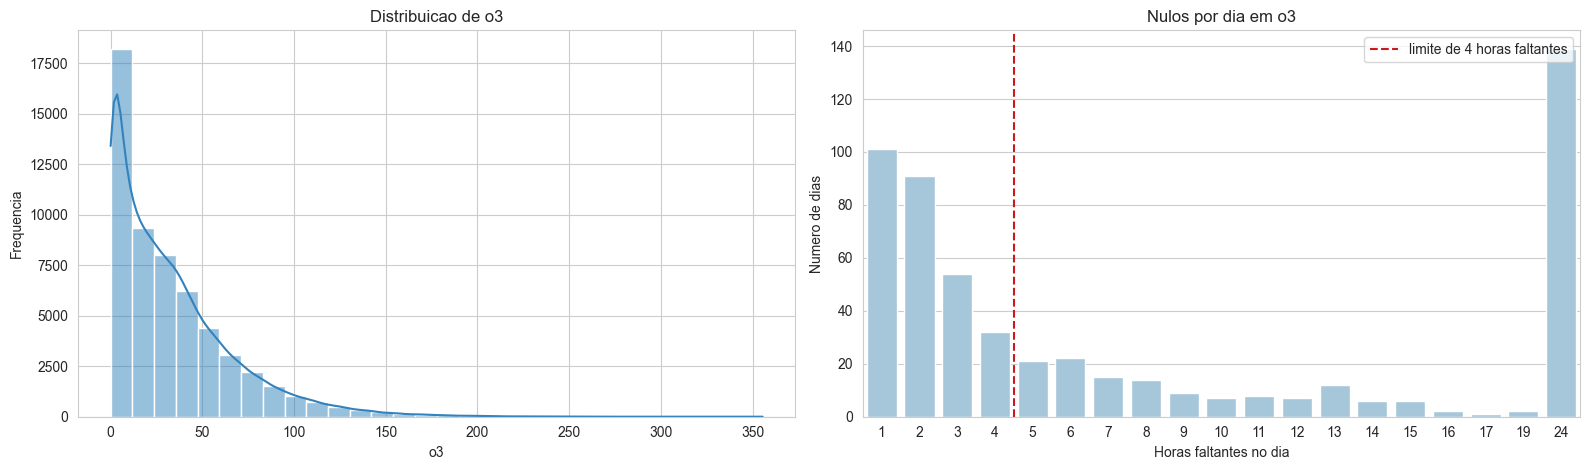

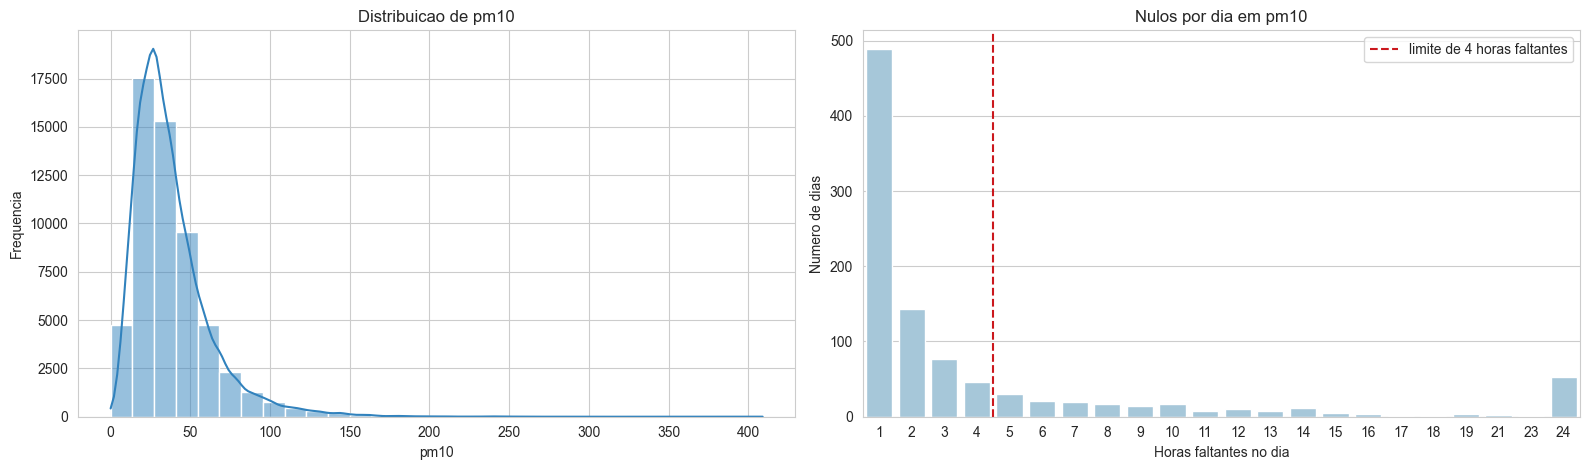

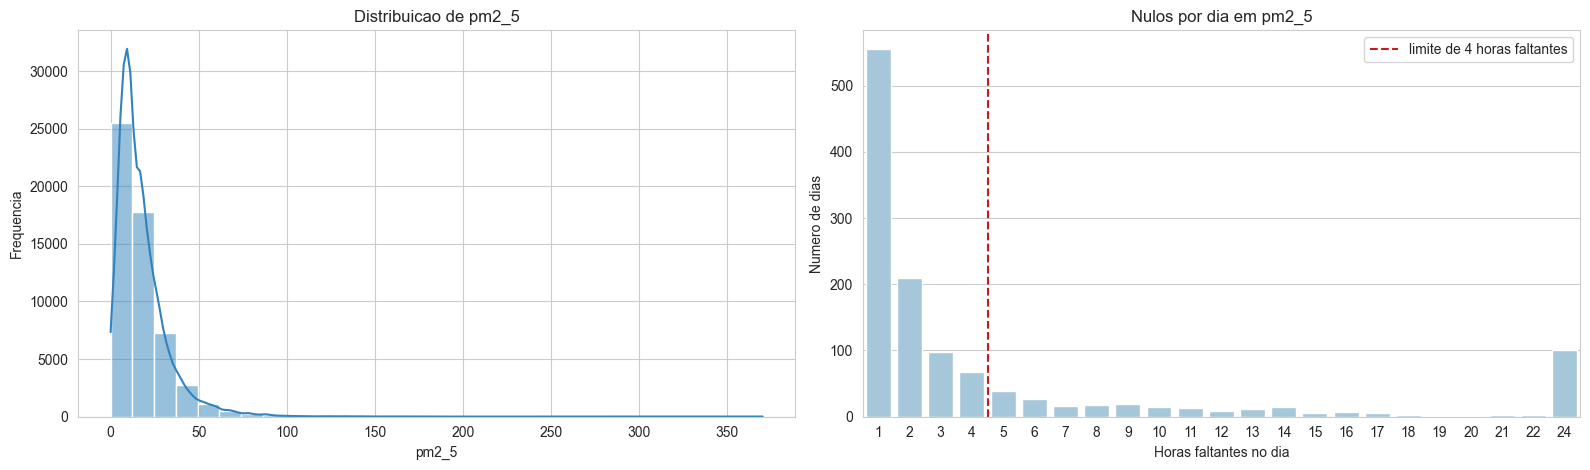

In [9]:
sns.set_style("whitegrid")

for variavel in variaveis_analise:
    serie = df_iraja_carac[variavel].dropna()
    faltantes_por_dia = distribuicoes_missing_diario[variavel]
    distribuicao_faltantes = (
        faltantes_por_dia.value_counts()
        .sort_index()
        .rename_axis("horas_faltantes")
        .reset_index(name="n_dias")
    )
    distribuicao_faltantes = distribuicao_faltantes[distribuicao_faltantes["horas_faltantes"] > 0].copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))

    if not serie.empty:
        sns.histplot(serie, bins=30, kde=True, color="#3182bd", ax=axes[0])
    else:
        axes[0].text(0.5, 0.5, "Sem valores validos", ha="center", va="center", transform=axes[0].transAxes)

    axes[0].set_title(f"Distribuicao de {variavel}")
    axes[0].set_xlabel(variavel)
    axes[0].set_ylabel("Frequencia")

    if not distribuicao_faltantes.empty:
        sns.barplot(data=distribuicao_faltantes, x="horas_faltantes", y="n_dias", color="#9ecae1", ax=axes[1])
        axes[1].axvline(3.5, color="#cb181d", linestyle="--", linewidth=1.5, label="limite de 4 horas faltantes")
        axes[1].legend(loc="upper right")
    else:
        axes[1].text(0.5, 0.5, "Sem dias com horas faltantes", ha="center", va="center", transform=axes[1].transAxes)

    axes[1].set_title(f"Nulos por dia em {variavel}")
    axes[1].set_xlabel("Horas faltantes no dia")
    axes[1].set_ylabel("Numero de dias")

    plt.tight_layout()
    plt.show()

## Resumo interpretativo dos resultados

Os resultados indicam que a estação de Irajá tem uma base **muito boa do ponto de vista temporal e operacional**, com cobertura contínua de `2012-01-01 00:30` a `2018-12-31 23:30`, frequência horária regular, ausência de timestamps faltantes, ausência de duplicatas de horário e nenhuma evidência de mudança de nome ou coordenadas. Isso sugere que, para esta estação, a estrutura temporal da série está íntegra e o principal cuidado analítico passa a ser a completude desigual entre as variáveis monitoradas, e não o calendário da base.

A leitura de missing por variável mostra uma separação clara de qualidade, mas sem indisponibilidades estruturais totais. Todas as séries principais estão presentes, o que é uma vantagem importante desta estação. Ainda assim, `so2` se destaca como a variável mais crítica em completude (`26,6%`), seguida por `ur` (`17,8%`). `pm2_5` (`9,7%`), `o3` (`8,3%`), `nox` (`8,2%`), `no` (`8,2%`) e `no2` (`8,2%`) apresentam perdas intermediárias, enquanto `temp` (`6,8%`), `pm10` (`6,6%`), `co` (`6,0%`) e `chuva` (`2,5%`) aparecem em condição relativamente melhor. Em termos práticos, Irajá tem um conjunto analítico mais completo do que várias outras estações, mas com necessidade real de controle de qualidade nas variáveis mais sensíveis.

As distribuições reforçam que a estação monitora processos bastante heterogêneos e com forte sinal de episódios agudos. Entre as variáveis meteorológicas, `chuva` segue fortemente concentrada em zero e muito assimétrica, enquanto `temp` e `ur` apresentam comportamento mais estável. Entre os poluentes, todas as séries mostram **assimetria à direita**, indicando predominância de valores usuais com alguns picos elevados; esse padrão é especialmente forte em `so2`, `no`, `nox`, `pm2_5` e `pm10`. Em Irajá, chama atenção o nível relativamente alto de `no2` (`42,0` de média), `nox` (`61,2`) e `pm10` (`38,0`), além de máximos muito elevados em `no`, `nox`, `o3`, `pm10`, `pm2_5` e `so2`. Isso sugere uma estação particularmente útil para estudar dinâmica de tráfego, mistura de poluentes secundários e episódios intensos de material particulado.

A distribuição diária de nulos também ajuda a separar o que é lacuna curta do que é perda mais severa. `pm10`, `pm2_5`, `no`, `no2`, `nox` e `co` concentram muitos dias completos e um volume expressivo de dias com apenas `1` a `4` horas faltantes, o que favorece estratégias de imputação pontual. `pm2_5`, em particular, chama atenção porque boa parte das horas faltantes totais está concentrada justamente em dias com lacunas curtas. `o3` também parece tratável em parte, embora já acumule mais dias severamente incompletos. `so2` e `ur` se destacam negativamente porque combinam missing total alto com muitos dias severamente incompletos, o que exige bem mais cautela. `temp` e `chuva` ficam em uma zona intermediária, com boa utilidade, mas sem a mesma folga observada em `pm10` ou `co`.

Em síntese, a estação de Irajá parece **muito forte como plataforma de monitoramento** no nível da base, porque combina cobertura temporal íntegra com um conjunto amplo de poluentes disponíveis. O principal cuidado analítico passa a ser tratar cada variável conforme sua qualidade: `so2` e `ur` exigem maior controle de completude, `o3`, `pm2_5`, `no`, `no2` e `nox` pedem acompanhamento intermediário, e `chuva`, `temp`, `co` e `pm10` aparecem como séries especialmente promissoras para as próximas etapas da EDA. Isso deixa claro que, em Irajá, a confiabilidade é alta tanto no nível da base quanto no potencial analítico, embora algumas variáveis ainda exijam tratamento mais cuidadoso antes de comparações ou modelagem.
